# Phase 2A: Condition Coverage & Therapeutic Area Analysis

Validates the condition dictionary (`ref.condition_dictionary`), study conditions (`norm.study_conditions`), and therapeutic area mapping (`norm.study_therapeutic_areas`).

**Key questions:**
1. How well does the condition dictionary cover free-text conditions?
2. What % of studies have at least one TA assignment?
3. How are studies distributed across TAs?
4. What are the top unmapped conditions (informs Phase 2C urgency)?

In [1]:
import sys
sys.path.insert(0, '..')

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

conn = duckdb.connect('../data/clinical_trials.duckdb', read_only=True)
print("Connected to DuckDB")

Connected to DuckDB


## 1. Condition Dictionary Coverage

In [2]:
total_studies = conn.execute("SELECT COUNT(DISTINCT nct_id) FROM raw.studies").fetchone()[0]
total_conditions = conn.execute("SELECT COUNT(*) FROM raw.conditions").fetchone()[0]
unique_conditions = conn.execute("SELECT COUNT(DISTINCT LOWER(name)) FROM raw.conditions").fetchone()[0]
dict_size = conn.execute("SELECT COUNT(*) FROM ref.condition_dictionary").fetchone()[0]

print(f"Total condition rows:      {total_conditions:,}")
print(f"Unique condition names:    {unique_conditions:,}")
print(f"Dictionary entries:        {dict_size:,} ({100*dict_size/unique_conditions:.1f}% of unique names)")

print("\nDictionary entries by method and confidence:")
dict_stats = conn.execute("""
    SELECT mapping_method, confidence, COUNT(*) as entries
    FROM ref.condition_dictionary
    GROUP BY mapping_method, confidence
    ORDER BY mapping_method, confidence
""").fetchdf()
print(dict_stats.to_string(index=False))

print("\nStudy-level condition coverage:")
studies_with_canonical = conn.execute(
    "SELECT COUNT(DISTINCT nct_id) FROM norm.study_conditions WHERE canonical_term IS NOT NULL"
).fetchone()[0]
mapped_rows = conn.execute(
    "SELECT COUNT(*) FROM norm.study_conditions WHERE canonical_term IS NOT NULL"
).fetchone()[0]
print(f"  Studies with ≥1 canonical condition: {studies_with_canonical:,}/{total_studies:,} ({100*studies_with_canonical/total_studies:.1f}%)")
print(f"  Condition rows mapped: {mapped_rows:,}/{total_conditions:,} ({100*mapped_rows/total_conditions:.1f}%)")

Total condition rows:      253,711
Unique condition names:    57,106
Dictionary entries:        19,209 (33.6% of unique names)

Dictionary entries by method and confidence:
mapping_method confidence  entries
     1:1-study       high     8263
cancer-synonym       high      350
 co-occurrence       high      247
 co-occurrence     medium     2465
         exact       high     3247
         fuzzy       high      544
         fuzzy        low     3007
         fuzzy     medium     1086

Study-level condition coverage:
  Studies with ≥1 canonical condition: 103,609/119,753 (86.5%)
  Condition rows mapped: 242,964/253,711 (95.8%)


## 2. Sample Mappings by Method (Spot-Check)

In [3]:
for method in ['exact', '1:1-study', 'co-occurrence', 'cancer-synonym', 'fuzzy']:
    print(f"\n=== {method} (10 samples) ===")
    sample = conn.execute(f"""
        SELECT condition_name, canonical_term, confidence
        FROM ref.condition_dictionary
        WHERE mapping_method = '{method}'
        ORDER BY condition_name
        LIMIT 10
    """).fetchdf()
    print(sample.to_string(index=False))


=== exact (10 samples) ===
                               condition_name                                canonical_term confidence
                    16p11.2 deletion syndrome                     16p11.2 Deletion Syndrome       high
                      22q11 deletion syndrome                       22q11 Deletion Syndrome       high
   3-hydroxyacyl-coa dehydrogenase deficiency    3-Hydroxyacyl-CoA Dehydrogenase Deficiency       high
3-methylcrotonyl coa carboxylase 1 deficiency 3-methylcrotonyl CoA carboxylase 1 deficiency       high
3-methylcrotonyl coa carboxylase 2 deficiency 3-methylcrotonyl CoA carboxylase 2 deficiency       high
                               aa amyloidosis                                AA amyloidosis       high
                               abdomen, acute                                Abdomen, Acute       high
                            abdominal abscess                             Abdominal Abscess       high
                           abdominal injuries

## 3. TA Coverage & Distribution

Studies with TA assignment: 93,606/119,753 (78.2%)



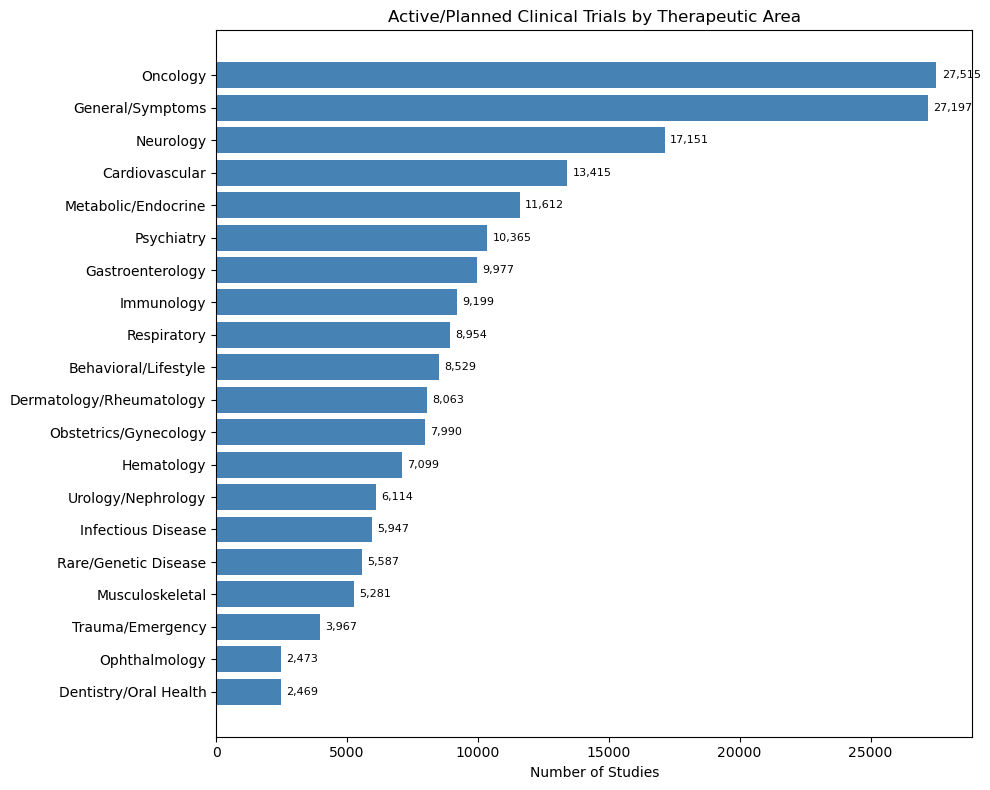

Note: Studies can appear in multiple TAs (multi-label). Total unique studies with TA: 93,606


In [4]:
studies_with_ta = conn.execute("SELECT COUNT(DISTINCT nct_id) FROM norm.study_therapeutic_areas").fetchone()[0]
print(f"Studies with TA assignment: {studies_with_ta:,}/{total_studies:,} ({100*studies_with_ta/total_studies:.1f}%)\n")

ta_dist = conn.execute("""
    SELECT therapeutic_area,
           COUNT(DISTINCT nct_id) AS study_count
    FROM norm.study_therapeutic_areas
    GROUP BY therapeutic_area
    ORDER BY study_count DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(ta_dist['therapeutic_area'][::-1], ta_dist['study_count'][::-1], color='steelblue')
ax.set_xlabel('Number of Studies')
ax.set_title('Active/Planned Clinical Trials by Therapeutic Area')
for i, (ta, count) in enumerate(zip(ta_dist['therapeutic_area'][::-1], ta_dist['study_count'][::-1])):
    ax.text(count + 200, i, f'{count:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Note: Studies can appear in multiple TAs (multi-label). Total unique studies with TA: {studies_with_ta:,}")

## 4. Multi-label Analysis & Top Unmapped Conditions

Therapeutic areas per study:
 ta_count  num_studies
        1        29976
        2        36795
        3        17474
        4         6220
        5         1920
        6          671
        7          295
        8          118
        9           68
       10           31
       11           16
       12            8
       13            4
       14            5
       16            2
       17            1
       18            2


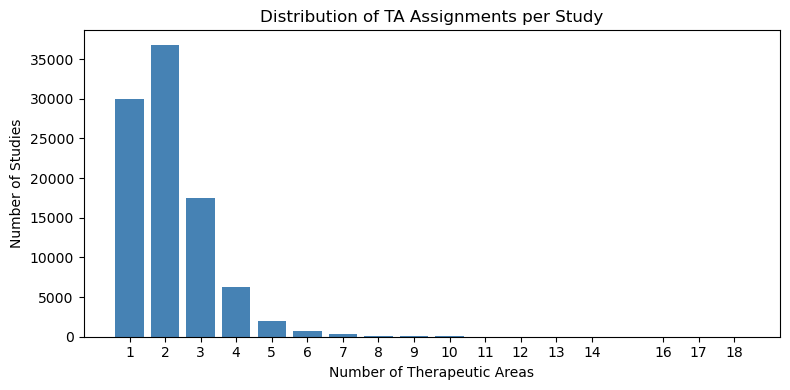

In [5]:
ta_per_study = conn.execute("""
    SELECT ta_count, COUNT(*) AS num_studies
    FROM (
        SELECT nct_id, COUNT(DISTINCT therapeutic_area) AS ta_count
        FROM norm.study_therapeutic_areas
        GROUP BY nct_id
    )
    GROUP BY ta_count
    ORDER BY ta_count
""").fetchdf()

print("Therapeutic areas per study:")
print(ta_per_study.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ta_per_study['ta_count'], ta_per_study['num_studies'], color='steelblue')
ax.set_xlabel('Number of Therapeutic Areas')
ax.set_ylabel('Number of Studies')
ax.set_title('Distribution of TA Assignments per Study')
ax.set_xticks(ta_per_study['ta_count'])
plt.tight_layout()
plt.show()

## 5. Top Unmapped Conditions & Coverage Gap

In [6]:
unmapped = conn.execute("""
    SELECT condition_name, COUNT(DISTINCT nct_id) AS study_count
    FROM norm.study_conditions
    WHERE canonical_term IS NULL
    GROUP BY condition_name
    ORDER BY study_count DESC
    LIMIT 30
""").fetchdf()

print(f"Top 30 unmapped conditions (no canonical term in dictionary):\n")
print(unmapped.to_string(index=False))

print("\n\nCoverage gap breakdown:")
no_conditions = conn.execute("""
    SELECT COUNT(DISTINCT s.nct_id)
    FROM raw.studies s
    LEFT JOIN raw.conditions c ON s.nct_id = c.nct_id
    WHERE c.nct_id IS NULL
""").fetchone()[0]
has_conditions_no_browse = conn.execute("""
    SELECT COUNT(DISTINCT c.nct_id)
    FROM raw.conditions c
    LEFT JOIN raw.browse_conditions bc ON c.nct_id = bc.nct_id
    WHERE bc.nct_id IS NULL
""").fetchone()[0]
has_browse_no_ta = conn.execute("""
    SELECT COUNT(DISTINCT bc.nct_id)
    FROM raw.browse_conditions bc
    LEFT JOIN norm.study_therapeutic_areas sta ON bc.nct_id = sta.nct_id
    WHERE sta.nct_id IS NULL
""").fetchone()[0]

print(f"  Studies with no conditions at all:           {no_conditions:,}")
print(f"  Studies with conditions but no MeSH mapping: {has_conditions_no_browse:,}")
print(f"  Studies with MeSH mapping but no TA match:   {has_browse_no_ta:,}")
print(f"  Total without TA:                            {total_studies - studies_with_ta:,}")

Top 30 unmapped conditions (no canonical term in dictionary):

                             condition_name  study_count
                              Immunotherapy          162
                     Overweight and Obesity          160
                                   Children          125
          Advanced Malignant Solid Neoplasm          103
                       Obesity & Overweight          102
                     Obesity and Overweight           93
                        Depression, Anxiety           90
               Artificial Intelligence (AI)           87
                               Chemotherapy           86
Hematopoietic and Lymphatic System Neoplasm           76
                                  Parenting           76
                           Healthy Subjects           74
                        Chemotherapy Effect           73
                                 Ultrasound           73
                                    Elderly           70
                    Artif

  Studies with no conditions at all:           9
  Studies with conditions but no MeSH mapping: 25,438
  Studies with MeSH mapping but no TA match:   700
  Total without TA:                            26,147


## 6. Fuzzy & Low-Confidence Mappings (Review Candidates)

In [7]:
print("=== Fuzzy high-confidence (spot-check) ===")
print(conn.execute("""
    SELECT condition_name, canonical_term
    FROM ref.condition_dictionary
    WHERE mapping_method = 'fuzzy' AND confidence = 'high'
    ORDER BY condition_name
    LIMIT 15
""").fetchdf().to_string(index=False))

print("\n=== Fuzzy medium-confidence (review candidates) ===")
print(conn.execute("""
    SELECT condition_name, canonical_term
    FROM ref.condition_dictionary
    WHERE mapping_method = 'fuzzy' AND confidence = 'medium'
    ORDER BY condition_name
    LIMIT 15
""").fetchdf().to_string(index=False))

print("\n=== Fuzzy low-confidence (singletons, noisiest) ===")
print(conn.execute("""
    SELECT condition_name, canonical_term
    FROM ref.condition_dictionary
    WHERE mapping_method = 'fuzzy' AND confidence = 'low'
    ORDER BY condition_name
    LIMIT 15
""").fetchdf().to_string(index=False))

print("\n=== Summary by confidence ===")
print(conn.execute("""
    SELECT confidence, COUNT(*) as entries
    FROM ref.condition_dictionary
    WHERE mapping_method = 'fuzzy'
    GROUP BY confidence
    ORDER BY confidence
""").fetchdf().to_string(index=False))

=== Fuzzy high-confidence (spot-check) ===
                       condition_name           canonical_term
            acute alcoholic hepatitis     Hepatitis, Alcoholic
              acute aortic dissection        Aortic Dissection
                 acute brain injuries           Brain Injuries
                  acute bronchiolitis            Bronchiolitis
                 acute diverticulitis           Diverticulitis
                        acute dyspnea                  Dyspnea
                acute gastroenteritis          Gastroenteritis
          acute graft vs host disease    Graft vs Host Disease
             acute hemorrhagic stroke       Hemorrhagic Stroke
acute lymphocytic leukemia refractory Leukemia, Prolymphocytic
           acute malnutrition, severe             Malnutrition
            acute pain, postoperative      Pain, Postoperative
        acute pulmonary embolism (pe)       Pulmonary Embolism
                       acute pulpitis                 Pulpitis
            

In [8]:
conn.close()
print("Done.")

Done.
